In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

import gensim.downloader as api

In [2]:
file_path = "FinancialPhraseBank/FinancialPhraseBank-v1.0/Sentences_50Agree.txt"

texts = []
labels = []

with open(file_path, "r", encoding="latin-1") as file:
    for line in file:
        line = line.strip()
        
        if not line:
            continue
        
        text, label = line.rsplit("@", 1)
        texts.append(text)
        labels.append(label)

df = pd.DataFrame({
    "text": texts,
    "label": labels
})

df.head()

,text,label
0,"According to Gran , the company has no plans t...",neutral
1,Technopolis plans to develop in stages an area...,neutral
2,The international electronic industry company ...,negative
3,With the new production plant the company woul...,positive
4,According to the company 's updated strategy f...,positive


In [3]:
word_vectors = api.load("glove-wiki-gigaword-50")

In [4]:
def preprocess_for_similarity(text):
    
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = text.split()
    
    return tokens

In [5]:
positive_df = df[df["label"] == "positive"]
positive_sample = positive_df.sample(n=15, random_state=43)
positive_sample['tokens'] = positive_sample['text'].apply(preprocess_for_similarity)
display(positive_sample.head())

,text,label,tokens
344,Last year the company raised its turnover to a...,positive,"[last, year, the, company, raised, its, turnov..."
4786,Danske Bank A-S DANSKE DC jumped 3.7 percent t...,positive,"[danske, bank, a, s, danske, dc, jumped, 3, 7,..."
4467,The main strength of the cooperation project l...,positive,"[the, main, strength, of, the, cooperation, pr..."
4459,efficiency improvement measures 20 January 201...,positive,"[efficiency, improvement, measures, 20, januar..."
163,Both operating profit and net sales for the 12...,positive,"[both, operating, profit, and, net, sales, for..."


### Sentence Embeddings via averaging of the word vectors

In [ ]:
def sentence_vector(tokens, word_vectors):
    
    vectors = []
    
    for token in tokens:
        if token in word_vectors:
            vectors.append(word_vectors[token])

    if len(vectors) == 0:
        return np.zeros(word_vectors.vector_size)

    return np.mean(vectors, axis=0)


def count_known_tokens(tokens, word_vectors):
    return sum(1 for token in tokens if token in word_vectors)

def process_sample(sample_df):

    sample_df["sentence_vector"] = sample_df["tokens"].apply(
    lambda tokens: sentence_vector(tokens, word_vectors)
    )

    sample_df["Numer of Tokens"] = sample_df["tokens"].apply(len)

    sample_df["known_tokens"] = sample_df["tokens"].apply(
        lambda tokens: count_known_tokens(tokens, word_vectors)
    )

    return sample_df

In [15]:
display(process_sample(positive_sample))

,text,label,tokens,sentence_vector,Numer of Tokens,known_tokens
344,Last year the company raised its turnover to a...,positive,"[last, year, the, company, raised, its, turnov...","[0.24600257, 0.14771877, 0.66450065, 0.0739382...",22,22
4786,Danske Bank A-S DANSKE DC jumped 3.7 percent t...,positive,"[danske, bank, a, s, danske, dc, jumped, 3, 7,...","[-0.11307084, 0.123927616, 0.829752, 0.0594786...",22,22
4467,The main strength of the cooperation project l...,positive,"[the, main, strength, of, the, cooperation, pr...","[0.5919518, 0.24714117, -0.09039469, 0.1793488...",17,17
4459,efficiency improvement measures 20 January 201...,positive,"[efficiency, improvement, measures, 20, januar...","[0.30261448, 0.009565215, 0.14820977, 0.024709...",32,30
163,Both operating profit and net sales for the 12...,positive,"[both, operating, profit, and, net, sales, for...","[0.0949019, 0.24429473, 0.45740798, 0.08990712...",25,23
752,"According to CEO Matti Karppinen , Frozen Food...",positive,"[according, to, ceo, matti, karppinen, frozen,...","[0.110482946, 0.1356615, -0.0678666, 0.2268916...",18,18
2099,Finnish elevators and escalators maker KONE Co...,positive,"[finnish, elevators, and, escalators, maker, k...","[0.2686652, 0.15149689, 0.12624608, 0.07230729...",39,39
598,The six breweries recorded a 5.2 percent growt...,positive,"[the, six, breweries, recorded, a, 5, 2, perce...","[0.19107132, 0.06446543, 0.60231864, 0.0160806...",28,28
2203,The companies expect the first orders already ...,positive,"[the, companies, expect, the, first, orders, a...","[0.2793489, -0.12352554, 0.083526336, 0.073716...",9,9
268,"Pre-tax profit totaled EUR 397.4 mn , up from ...",positive,"[pre, tax, profit, totaled, eur, 397, 4, mn, u...","[0.126714, 0.18043177, 0.89219815, -0.17887473...",14,14


### Smilarity

In [8]:
def manual_cosine_similarity(vec_a, vec_b):
    
    dot_product = np.dot(vec_a, vec_b)
    norm_a = np.linalg.norm(vec_a)
    norm_b = np.linalg.norm(vec_b)
    
    if norm_a == 0 or norm_b == 0:
        return 0.0
    
    return dot_product / (norm_a * norm_b)

In [9]:
sentence_vectors = list(positive_sample["sentence_vector"])

n = len(sentence_vectors)
similarity_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        similarity_matrix[i, j] = manual_cosine_similarity(
            sentence_vectors[i],
            sentence_vectors[j]
        )

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=[f"S{i+1}" for i in range(n)],
    columns=[f"S{i+1}" for i in range(n)]
)

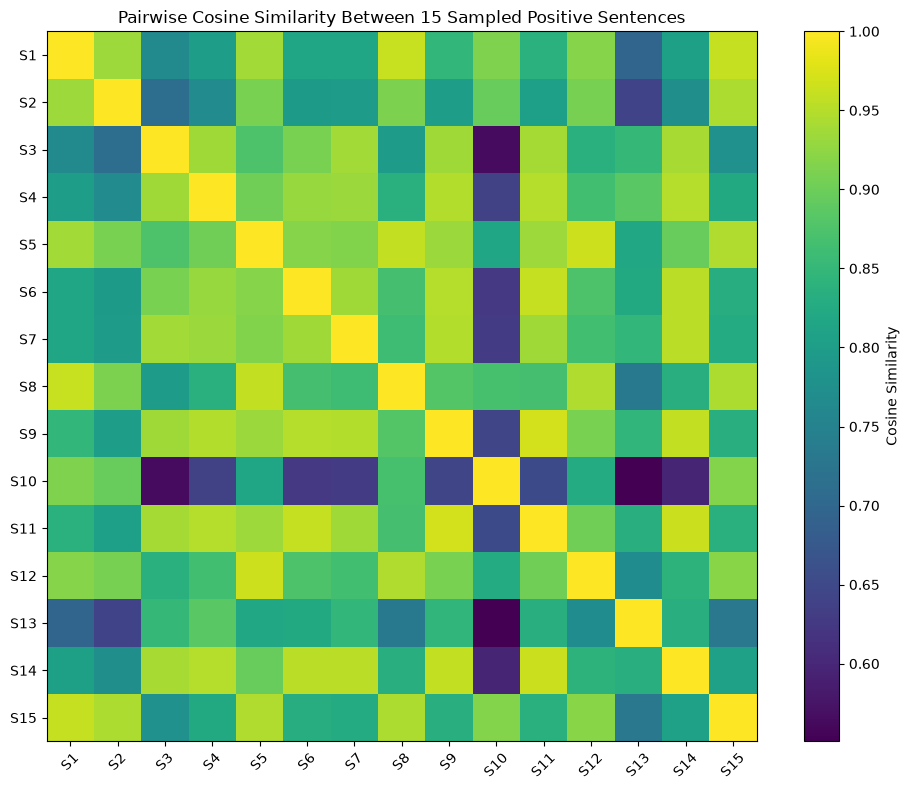

In [10]:
plt.figure(figsize=(10, 8))
plt.imshow(similarity_matrix)
plt.colorbar(label="Cosine Similarity")

plt.xticks(range(n), [f"S{i+1}" for i in range(n)], rotation=45)
plt.yticks(range(n), [f"S{i+1}" for i in range(n)])

plt.title("Pairwise Cosine Similarity Between 15 Sampled Positive Sentences")
plt.tight_layout()
plt.show()

### Most similar

In [11]:
pairs = []

for i in range(n):
    for j in range(i + 1, n):
        pairs.append({
            "sentence_1_id": f"S{i+1}",
            "sentence_2_id": f"S{j+1}",
            "similarity": similarity_matrix[i, j],
            "sentence_1": positive_sample.iloc[i]["text"],
            "sentence_2": positive_sample.iloc[j]["text"]
        })

pairs_df = pd.DataFrame(pairs)

most_similar = pairs_df.sort_values(by="similarity", ascending=False).head(5)
most_similar

,sentence_1_id,sentence_2_id,similarity,sentence_1,sentence_2
85,S9,S11,0.969607,The companies expect the first orders already ...,`` Following last year 's good profit developm...
56,S5,S12,0.965484,Both operating profit and net sales for the 12...,"Earnings per share ( EPS ) were EUR0 .03 , up ..."
97,S11,S14,0.964801,`` Following last year 's good profit developm...,Atria will launch a campaign in September to p...
6,S1,S8,0.962058,Last year the company raised its turnover to a...,The six breweries recorded a 5.2 percent growt...
64,S6,S11,0.960259,"According to CEO Matti Karppinen , Frozen Food...",`` Following last year 's good profit developm...


### Least similar

In [12]:
least_similar = pairs_df.sort_values(by="similarity", ascending=True).head(5)
least_similar

,sentence_1_id,sentence_2_id,similarity,sentence_1,sentence_2
92,S10,S13,0.550820,"Pre-tax profit totaled EUR 397.4 mn , up from ...",To ensure low operational cost for radio netwo...
33,S3,S10,0.563931,The main strength of the cooperation project l...,"Pre-tax profit totaled EUR 397.4 mn , up from ..."
93,S10,S14,0.596445,"Pre-tax profit totaled EUR 397.4 mn , up from ...",Atria will launch a campaign in September to p...
63,S6,S10,0.624697,"According to CEO Matti Karppinen , Frozen Food...","Pre-tax profit totaled EUR 397.4 mn , up from ..."
71,S7,S10,0.630776,Finnish elevators and escalators maker KONE Co...,"Pre-tax profit totaled EUR 397.4 mn , up from ..."


### Full text samples

In [13]:
for i, text in enumerate(positive_sample["text"], start=1):
    print(f"S{i}: {text}")

S1: Last year the company raised its turnover to approximately 7 million litas EUR 2 mln , from 6.1 million litas in 2004 .
S2: Danske Bank A-S DANSKE DC jumped 3.7 percent to 133.4 kroner , rebounding from yesterday s 3.5 percent slide .
S3: The main strength of the cooperation project lies in merging the know-how of two large companies .
S4: efficiency improvement measures 20 January 2010 - Finnish stationery and gift retailer Tiimari HEL : TII1V said today that it will continue to improve its operational efficiency , by focusing on its profitable core operations .
S5: Both operating profit and net sales for the 12-month period increased , respectively from EUR21 .5 m and EUR196 .1 m , as compared to 2005 .
S6: According to CEO Matti Karppinen , Frozen Foods posted a good result in 2010 , as it did in 2009 .
S7: Finnish elevators and escalators maker KONE Corporation said on Tuesday ( 18 March ) that it has received a major order from Sir Robert McAlpine to supply all elevators and e